# GPT 사전 학습 / 감성 분류 실험 노트북

이 노트북은 직접 만든 GPT 모델을 한국어 데이터로 사전 학습하고, 그 backbone을 감성 분류기로 fine-tuning하기 위한 실험 노트북입니다.

전체 흐름은 다음과 같습니다.

1. NSMC 영화 리뷰 텍스트로 BPE 토크나이저를 만들고 언어 모델용 token id를 준비합니다.
2. GPT 사전 학습에서 warmup, cosine decay, gradient clipping, weight decay를 적용해 loss가 안정적으로 내려가는지 봅니다.
3. batch size, dropout, learning rate, context length, layer 수, embedding 크기를 바꿔 validation loss가 좋은 조합을 찾습니다.
4. 사전 학습된 GPT backbone 위에 감성 분류 head를 붙이고, NSMC + 네이버 쇼핑 + Steam 리뷰로 긍정/부정을 학습합니다.
5. epoch별 loss/accuracy 그래프, class/source 분포 그래프, 별점 요약으로 어떤 설정이 나았는지 분석합니다.

처음에는 `QUICK_MODE = True`로 작은 샘플만 돌려서 코드가 정상 동작하는지 확인하세요. GPU가 잘 잡히고 학습이 돌아가는 걸 확인한 뒤 `QUICK_MODE = False`로 바꾸면 더 큰 데이터와 더 많은 조합을 사용합니다.


## 실행 전 확인

GPU로 학습하려면 PyTorch CUDA 설치가 되어 있어야 합니다. 설정 셀에서 `device: cuda`가 출력되면 GPU를 사용합니다. `device: cpu`가 나오면 학습이 매우 느리므로 CUDA 설치나 노트북 커널 환경을 확인하세요.

추가 감성 데이터는 이미 `download_extra_sentiment_data.py`로 받을 수 있게 해두었습니다. `data/combined_sentiment_train.jsonl`이 있으면 감성 분류는 자동으로 NSMC + 네이버 쇼핑 + Steam 합본을 사용합니다.


In [ ]:
# 필요한 경우 한 번만 실행하세요.
# %pip install -r requirements.txt


In [30]:
from pathlib import Path
import json
import math
import random
import sys
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

print('python:', sys.executable)
print('torch:', torch.__version__)
print('torch cuda build:', torch.version.cuda)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))

repo_dir = Path.cwd()
if not (repo_dir / 'src').exists():
    repo_dir = Path.cwd() / 'week14-team02-gpt-lab'
sys.path.insert(0, str(repo_dir / 'src'))

from bpe import BPETokenizer
from dataset import create_dataloader
from model import GPTModel
from train import calc_loss_batch, calc_loss_loader, generate_and_print_sample
from finetune import ReviewSentimentDataset, GPTForSequenceClassification, evaluate_sentiment

DATA_DIR = repo_dir / 'data'
RUN_DIR = repo_dir / 'runs'
CKPT_DIR = RUN_DIR / 'checkpoints'
PLOT_DIR = RUN_DIR / 'plots'
for path in [RUN_DIR, CKPT_DIR, PLOT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

QUICK_MODE = False
SEED = 42
SEEDS = [42] if QUICK_MODE else [42, 123]


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('repo_dir:', repo_dir)
print('device:', device)

# GPU 학습을 의도했는데 여기서 cpu가 나오면 노트북 커널이 CUDA PyTorch가 설치된 Python과 다릅니다.
# 그 경우 아래 명령으로 현재 Python을 Jupyter 커널로 등록한 뒤, 노트북 우상단 커널을 바꾸세요.
# py -m pip install ipykernel
# py -m ipykernel install --user --name krafton-gpu --display-name "Python 3.12 CUDA (krafton-gpu)"

python: d:\miniconda\envs\KraftonJungle_LLM_env\python.exe
torch: 2.11.0+cu128
torch cuda build: 12.8
cuda available: True
gpu: NVIDIA GeForce RTX 4050 Laptop GPU
repo_dir: c:\Users\haeli\Desktop\Krafton_Jungle\llm\week14-team02-gpt-lab
device: cuda


## 1. 데이터와 토크나이저 준비

### 데이터 준비에서 보는 것

이 단계는 두 종류의 데이터를 준비합니다.

- 언어 모델 사전 학습용: 리뷰 문장을 이어붙인 텍스트를 BPE로 token id로 변환합니다.
- 감성 분류용: `text`, `label` 형태의 JSONL 데이터를 읽습니다. label은 `0=부정`, `1=긍정`입니다.

`QUICK_MODE=True`일 때는 토크나이저와 언어 모델 학습 데이터 일부만 사용합니다. 전체 데이터로 돌리려면 `QUICK_MODE=False`로 바꿔야 합니다.


In [31]:
LM_TRAIN_PATH = DATA_DIR / 'nsmc_lm_train.txt'
LM_VAL_PATH = DATA_DIR / 'nsmc_lm_val.txt'
SENT_TRAIN_PATH = DATA_DIR / 'nsmc_sentiment_train.jsonl'
SENT_VAL_PATH = DATA_DIR / 'nsmc_sentiment_val.jsonl'
SENT_TEST_PATH = DATA_DIR / 'nsmc_sentiment_test.jsonl'
COMBINED_SENT_TRAIN_PATH = DATA_DIR / 'combined_sentiment_train.jsonl'
COMBINED_SENT_VAL_PATH = DATA_DIR / 'combined_sentiment_val.jsonl'
COMBINED_SENT_TEST_PATH = DATA_DIR / 'combined_sentiment_test.jsonl'

train_text = LM_TRAIN_PATH.read_text(encoding='utf-8')
val_text = LM_VAL_PATH.read_text(encoding='utf-8')

if QUICK_MODE:
    train_text_for_tokenizer = train_text[:50_000]
    train_text_for_lm = train_text[:80_000]
    val_text_for_lm = val_text[:20_000]
    tokenizer_vocab_size = 700
else:
    train_text_for_tokenizer = train_text[:1_500_000]
    train_text_for_lm = train_text
    val_text_for_lm = val_text
    tokenizer_vocab_size = 3000

tokenizer_path = RUN_DIR / f'bpe_vocab_{tokenizer_vocab_size}.json'
tokenizer = BPETokenizer(vocab_size=tokenizer_vocab_size)
if tokenizer_path.exists():
    tokenizer.load(tokenizer_path)
    print('loaded tokenizer:', tokenizer_path)
else:
    tokenizer.train(train_text_for_tokenizer)
    tokenizer.save(tokenizer_path)
    print('trained tokenizer:', tokenizer_path)

mode_name = 'quick' if QUICK_MODE else 'full'
train_ids_path = RUN_DIR / f'train_ids_{mode_name}_v{tokenizer_vocab_size}.json'
val_ids_path = RUN_DIR / f'val_ids_{mode_name}_v{tokenizer_vocab_size}.json'
if train_ids_path.exists() and val_ids_path.exists():
    train_ids = json.loads(train_ids_path.read_text(encoding='utf-8'))
    val_ids = json.loads(val_ids_path.read_text(encoding='utf-8'))
    print('loaded token ids:', train_ids_path, val_ids_path)
else:
    train_ids = tokenizer.encode(train_text_for_lm)
    val_ids = tokenizer.encode(val_text_for_lm)
    train_ids_path.write_text(json.dumps(train_ids), encoding='utf-8')
    val_ids_path.write_text(json.dumps(val_ids), encoding='utf-8')
    print('encoded and saved token ids:', train_ids_path, val_ids_path)
print('train chars:', len(train_text_for_lm), 'train tokens:', len(train_ids))
print('val chars:', len(val_text_for_lm), 'val tokens:', len(val_ids))

loaded tokenizer: c:\Users\haeli\Desktop\Krafton_Jungle\llm\week14-team02-gpt-lab\runs\bpe_vocab_1000.json
loaded token ids: c:\Users\haeli\Desktop\Krafton_Jungle\llm\week14-team02-gpt-lab\runs\train_ids_full_v1000.json c:\Users\haeli\Desktop\Krafton_Jungle\llm\week14-team02-gpt-lab\runs\val_ids_full_v1000.json
train chars: 1379486 train tokens: 1138662
val chars: 120560 val tokens: 99258


## 2. 공통 유틸리티

### 공통 유틸리티 설명

이 셀에는 실험을 반복하기 위한 보조 함수가 들어 있습니다.

- `make_gpt_config`: GPT 모델 크기와 dropout 설정을 만듭니다.
- `cosine_lr`: warmup 이후 cosine decay로 learning rate를 줄입니다.
- `plot_metric`: epoch별 loss/accuracy를 선 그래프로 그립니다.
- `star_rating`: 실험 결과를 최저 validation loss 또는 최고 accuracy 기준 별점으로 표시합니다.
- `load_jsonl`, `save_jsonl`: 실험 로그와 감성 데이터를 JSONL로 읽고 씁니다.


In [32]:
def make_gpt_config(vocab_size, context_length=64, emb_dim=64, n_layers=1, drop_rate=0.1, n_heads=4):
    if emb_dim % n_heads != 0:
        raise ValueError('emb_dim must be divisible by n_heads')
    return {
        'vocab_size': vocab_size,
        'context_length': context_length,
        'emb_dim': emb_dim,
        'n_heads': n_heads,
        'n_layers': n_layers,
        'drop_rate': drop_rate,
        'qkv_bias': False,
    }

def cosine_lr(step, total_steps, max_lr, min_lr=1e-5, warmup_steps=0):
    if step < warmup_steps:
        return max_lr * float(step + 1) / float(max(1, warmup_steps))
    progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    progress = min(1.0, max(0.0, progress))
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return min_lr + (max_lr - min_lr) * cosine

def plot_metric(history, title, keys, save_name=None):
    plt.figure(figsize=(8, 4))
    for key in keys:
        values = [row[key] for row in history if key in row]
        if values:
            plt.plot(range(1, len(values) + 1), values, marker='o', label=key)
    plt.title(title)
    plt.xlabel('epoch')
    plt.grid(alpha=0.3)
    plt.legend()
    if save_name:
        plt.savefig(PLOT_DIR / save_name, dpi=150, bbox_inches='tight')
    plt.show()

def star_rating(value, best, mode='min'):
    if value is None or not np.isfinite(value):
        return '☆'
    if mode == 'min':
        ratio = best / max(value, 1e-12)
    else:
        ratio = value / max(best, 1e-12)
    if ratio >= 0.98:
        return '★★★★★'
    if ratio >= 0.95:
        return '★★★★☆'
    if ratio >= 0.90:
        return '★★★☆☆'
    if ratio >= 0.80:
        return '★★☆☆☆'
    return '★☆☆☆☆'

def save_jsonl(path, rows):
    with Path(path).open('w', encoding='utf-8') as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + '\n')

def load_jsonl(path, limit=None):
    rows = []
    with Path(path).open(encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit is not None and i >= limit:
                break
            rows.append(json.loads(line))
    return rows

def summarize_seed_results(rows, metric, mode='min'):
    grouped = {}
    for row in rows:
        key = row.get('experiment_group', row.get('experiment', 'unknown'))
        grouped.setdefault(key, []).append(row[metric])
    summary = []
    for key, values in grouped.items():
        arr = np.array(values, dtype=float)
        summary.append({
            'experiment_group': key,
            'metric': metric,
            'mode': mode,
            'n_seeds': int(len(arr)),
            'mean': float(arr.mean()),
            'std': float(arr.std(ddof=1)) if len(arr) > 1 else 0.0,
            'min': float(arr.min()),
            'max': float(arr.max()),
        })
    reverse = mode == 'max'
    return sorted(summary, key=lambda x: x['mean'], reverse=reverse)


def print_seed_summary(summary):
    if not summary:
        print('No seed summary yet.')
        return
    best = summary[0]['mean']
    mode = summary[0]['mode']
    print('experiment_group | n | mean | std | min | max | stars')
    for row in summary:
        stars = star_rating(row['mean'], best, mode=mode)
        print(f"{row['experiment_group']} | {row['n_seeds']} | {row['mean']:.4f} | {row['std']:.4f} | {row['min']:.4f} | {row['max']:.4f} | {stars}")


def plot_seed_summary(summary, title, save_name=None):
    if not summary:
        print('No seed summary yet.')
        return
    labels = [row['experiment_group'] for row in summary]
    means = [row['mean'] for row in summary]
    stds = [row['std'] for row in summary]
    plt.figure(figsize=(max(7, len(labels) * 1.4), 4))
    plt.bar(range(len(labels)), means, yerr=stds, capsize=4)
    plt.xticks(range(len(labels)), labels, rotation=30, ha='right')
    plt.title(title)
    plt.ylabel(summary[0]['metric'])
    plt.grid(axis='y', alpha=0.3)
    if save_name:
        plt.savefig(PLOT_DIR / save_name, dpi=150, bbox_inches='tight')
    plt.show()


## 3. 7.1 사전 학습 성능 향상 실험

학습률 warmup, cosine decay, gradient clipping, weight decay를 포함한 사전 학습 루프입니다.

### 7.1 실험의 목적

이 실험은 단순히 AdamW로 학습하는 것보다 학습을 더 안정적으로 만드는 기법을 적용합니다.

- Warmup: 초반 learning rate를 천천히 키워서 학습 초반 발산을 줄입니다.
- Cosine decay: 학습 후반으로 갈수록 learning rate를 부드럽게 낮춰 세밀하게 수렴하게 합니다.
- Gradient clipping: gradient norm이 너무 커질 때 잘라서 폭주를 막습니다.
- Weight decay: 가중치가 과하게 커지는 것을 억제해 일반화를 돕습니다.

분석할 때는 `train_loss`와 `val_loss`가 함께 내려가는지, 둘 사이 간격이 너무 벌어지는지 봅니다. train loss만 내려가고 val loss가 오르면 과적합 가능성이 있습니다.


loaded cached LM checkpoint: c:\Users\haeli\Desktop\Krafton_Jungle\llm\week14-team02-gpt-lab\runs\checkpoints\lm_warmup_cosine_clip_wd_best_lm.pt


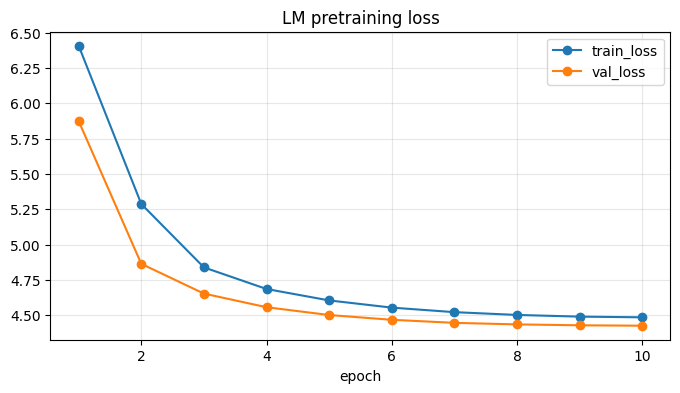

best lm checkpoint: c:\Users\haeli\Desktop\Krafton_Jungle\llm\week14-team02-gpt-lab\runs\checkpoints\lm_warmup_cosine_clip_wd_best_lm.pt


In [33]:
def train_lm_experiment(name, config, train_ids, val_ids, batch_size=4, lr=3e-4, weight_decay=0.01,
                        num_epochs=3, warmup_ratio=0.1, min_lr=1e-5, grad_clip=1.0,
                        eval_iter=20, save_best=True, use_cache=True):
    train_loader = create_dataloader(train_ids, context_length=config['context_length'], batch_size=batch_size,
                                     stride=config['context_length'], drop_last=True, shuffle=True)
    val_loader = create_dataloader(val_ids, context_length=config['context_length'], batch_size=batch_size,
                                   stride=config['context_length'], drop_last=False, shuffle=False)
    model = GPTModel(config).to(device)
    best_path = CKPT_DIR / f'{name}_best_lm.pt'
    if use_cache and best_path.exists():
        ckpt = torch.load(best_path, map_location=device)
        saved_config = ckpt.get('config')
        history = ckpt.get('history', [])
        saved_args = history[-1] if history else {}
        args_match = (
            saved_args.get('batch_size') == batch_size
            and saved_args.get('learning_rate') == lr
            and len(history) >= num_epochs
        )
        if saved_config == config and args_match:
            model.load_state_dict(ckpt['model_state_dict'])
            print('loaded cached LM checkpoint:', best_path)
            return model, history, best_path
        print('checkpoint exists but config changed, retraining:', best_path)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = max(1, len(train_loader) * num_epochs)
    warmup_steps = int(total_steps * warmup_ratio)
    history = []
    best_val_loss = float('inf')
    global_step = 0
    tokens_seen = 0
    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_losses = []
        for input_batch, target_batch in train_loader:
            current_lr = cosine_lr(global_step, total_steps, lr, min_lr=min_lr, warmup_steps=warmup_steps)
            for group in optimizer.param_groups:
                group['lr'] = current_lr

            optimizer.zero_grad(set_to_none=True)
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            epoch_losses.append(loss.item())
            tokens_seen += input_batch.numel()
            global_step += 1

        train_loss = float(np.mean(epoch_losses))
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
        row = {
            'experiment': name,
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': float(val_loss),
            'lr': optimizer.param_groups[0]['lr'],
            'tokens_seen': tokens_seen,
            'global_step': global_step,
            'seconds': round(time.time() - start_time, 2),
            **config,
            'batch_size': batch_size,
            'learning_rate': lr,
            'weight_decay': weight_decay,
            'warmup_ratio': warmup_ratio,
            'grad_clip': grad_clip,
        }
        history.append(row)
        print(f"[{name}] epoch {epoch}/{num_epochs} train={train_loss:.4f} val={val_loss:.4f} lr={row['lr']:.6g}")

        if save_best and val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({'model_state_dict': model.state_dict(), 'config': config, 'history': history}, best_path)

    return model, history, best_path

base_config = make_gpt_config(
    vocab_size=tokenizer_vocab_size,
    context_length=128,
    emb_dim=128,
    n_layers=2,
    drop_rate=0.1,
)

lm_epochs = 1 if QUICK_MODE else 5
lm_model, lm_history, lm_best_path = train_lm_experiment(
    name='lm_warmup_cosine_clip_wd',
    config=base_config,
    train_ids=train_ids,
    val_ids=val_ids,
    batch_size=4,
    lr=3e-4,
    weight_decay=0.01,
    num_epochs=lm_epochs,
    warmup_ratio=0.1,
    min_lr=1e-5,
    grad_clip=1.0,
)
save_jsonl(RUN_DIR / 'lm_history.jsonl', lm_history)
plot_metric(lm_history, 'LM pretraining loss', ['train_loss', 'val_loss'], 'lm_pretraining_loss.png')
print('best lm checkpoint:', lm_best_path)

## 4. 7.2 하이퍼파라미터 탐색

`QUICK_MODE=True`이면 후보 전체를 다 돌리지 않고 일부 조합만 확인합니다. 전체 탐색은 시간이 오래 걸리므로 `False`로 바꾼 뒤 실행하세요.

### 7.2 탐색 결과 해석

하이퍼파라미터 탐색은 같은 데이터에서 여러 모델 설정을 짧게 학습한 뒤 validation loss를 비교합니다.

비교 후보는 다음 의미를 가집니다.

- `batch_size`: 한 번 업데이트할 때 보는 샘플 수입니다. 크면 안정적이지만 메모리를 많이 씁니다.
- `drop_rate`: dropout 비율입니다. 높으면 과적합을 줄일 수 있지만 너무 높으면 학습이 느려집니다.
- `learning_rate`: 업데이트 크기입니다. 너무 크면 발산하고 너무 작으면 느립니다.
- `context_length`: 모델이 한 번에 보는 토큰 길이입니다. 길수록 문맥은 좋아지지만 메모리 사용량이 큽니다.
- `n_layers`: Transformer block 수입니다. 깊을수록 표현력은 늘지만 느리고 과적합 위험도 있습니다.
- `emb_dim`: token embedding 차원입니다. 클수록 표현력이 늘지만 메모리와 시간이 늘어납니다.

막대그래프는 낮을수록 좋고, 별점은 best validation loss에 가까울수록 높게 표시됩니다. `QUICK_MODE`에서는 순위가 대략적인 sanity check일 뿐입니다.


In [34]:
def build_hparam_candidates():
    candidates = []

    # Stage 1: compare model capacity while keeping optimizer settings stable.
    base = {
        'batch_size': 4,
        'drop_rate': 0.1,
        'learning_rate': 3e-4,
    }
    model_shapes = [
        {'context_length': 128, 'n_layers': 1, 'emb_dim': 64},
        {'context_length': 128, 'n_layers': 1, 'emb_dim': 128},
        {'context_length': 128, 'n_layers': 2, 'emb_dim': 128},
        {'context_length': 128, 'n_layers': 2, 'emb_dim': 192},
    ]
    for shape in model_shapes:
        candidates.append({**base, **shape})

    # Stage 2: tune learning rate, dropout, and batch size around a strong medium model.
    tuned_shape = {'context_length': 128, 'n_layers': 2, 'emb_dim': 128}
    for learning_rate in [1e-4, 3e-4, 5e-4]:
        for drop_rate in [0.0, 0.1, 0.2]:
            candidates.append({
                **tuned_shape,
                'batch_size': 4,
                'drop_rate': drop_rate,
                'learning_rate': learning_rate,
            })
    for batch_size in [8]:
        candidates.append({
            **tuned_shape,
            'batch_size': batch_size,
            'drop_rate': 0.1,
            'learning_rate': 3e-4,
        })

    unique_candidates = []
    seen = set()
    for cand in candidates:
        key = tuple(sorted(cand.items()))
        if key not in seen:
            seen.add(key)
            unique_candidates.append(cand)
    return unique_candidates

hparam_candidates = build_hparam_candidates()
if QUICK_MODE:
    hparam_candidates = hparam_candidates[:3]
print('candidate count:', len(hparam_candidates))

candidate count: 16


In [36]:
hparam_results = []
search_epochs = 1 if QUICK_MODE else 2

for i, cand in enumerate(hparam_candidates, start=1):
    exp_name = f"hparam_{i:03d}_bs{cand['batch_size']}_do{cand['drop_rate']}_lr{cand['learning_rate']}_ctx{cand['context_length']}_L{cand['n_layers']}_E{cand['emb_dim']}"
    print('\n===', exp_name, '===')
    config = make_gpt_config(
        vocab_size=tokenizer_vocab_size,
        context_length=cand['context_length'],
        emb_dim=cand['emb_dim'],
        n_layers=cand['n_layers'],
        drop_rate=cand['drop_rate'],
    )
    try:
        _, hist, best_path = train_lm_experiment(
            name=exp_name,
            config=config,
            train_ids=train_ids,
            val_ids=val_ids,
            batch_size=cand['batch_size'],
            lr=cand['learning_rate'],
            weight_decay=0.01,
            num_epochs=search_epochs,
            warmup_ratio=0.1,
            grad_clip=1.0,
            eval_iter=10 if QUICK_MODE else 20,
        )
        best_val = min(row['val_loss'] for row in hist)
        hparam_results.append({**cand, 'experiment': exp_name, 'best_val_loss': best_val, 'best_path': str(best_path)})
    except RuntimeError as e:
        print('skipped because RuntimeError:', e)
        hparam_results.append({**cand, 'experiment': exp_name, 'best_val_loss': float('inf'), 'best_path': None, 'error': str(e)})
    save_jsonl(RUN_DIR / 'hparam_results.jsonl', hparam_results)

best_loss = min(r['best_val_loss'] for r in hparam_results)
ranked = sorted(hparam_results, key=lambda r: r['best_val_loss'])
for rank, row in enumerate(ranked, start=1):
    row['rank'] = rank
    row['stars'] = star_rating(row['best_val_loss'], best_loss, mode='min')

print('\nTop results')
for row in ranked[:10]:
    print(row['rank'], row['stars'], row['experiment'], 'best_val_loss=', row['best_val_loss'])


=== hparam_001_bs4_do0.1_lr0.0003_ctx64_L1_E64 ===
loaded cached LM checkpoint: c:\Users\haeli\Desktop\Krafton_Jungle\llm\week14-team02-gpt-lab\runs\checkpoints\hparam_001_bs4_do0.1_lr0.0003_ctx64_L1_E64_best_lm.pt

=== hparam_002_bs4_do0.1_lr0.0003_ctx64_L2_E64 ===
[hparam_002_bs4_do0.1_lr0.0003_ctx64_L2_E64] epoch 1/5 train=6.1091 val=5.2278 lr=0.00029126
[hparam_002_bs4_do0.1_lr0.0003_ctx64_L2_E64] epoch 2/5 train=5.0279 val=4.7398 lr=0.000227513
[hparam_002_bs4_do0.1_lr0.0003_ctx64_L2_E64] epoch 3/5 train=4.7688 val=4.6091 lr=0.000129838
[hparam_002_bs4_do0.1_lr0.0003_ctx64_L2_E64] epoch 4/5 train=4.6787 val=4.5656 lr=4.39366e-05
[hparam_002_bs4_do0.1_lr0.0003_ctx64_L2_E64] epoch 5/5 train=4.6457 val=4.5536 lr=1e-05

=== hparam_003_bs4_do0.1_lr0.0003_ctx64_L2_E128 ===
[hparam_003_bs4_do0.1_lr0.0003_ctx64_L2_E128] epoch 1/5 train=5.7002 val=4.7086 lr=0.00029126
[hparam_003_bs4_do0.1_lr0.0003_ctx64_L2_E128] epoch 2/5 train=4.6162 val=4.4172 lr=0.000227513
[hparam_003_bs4_do0.1_lr0.0

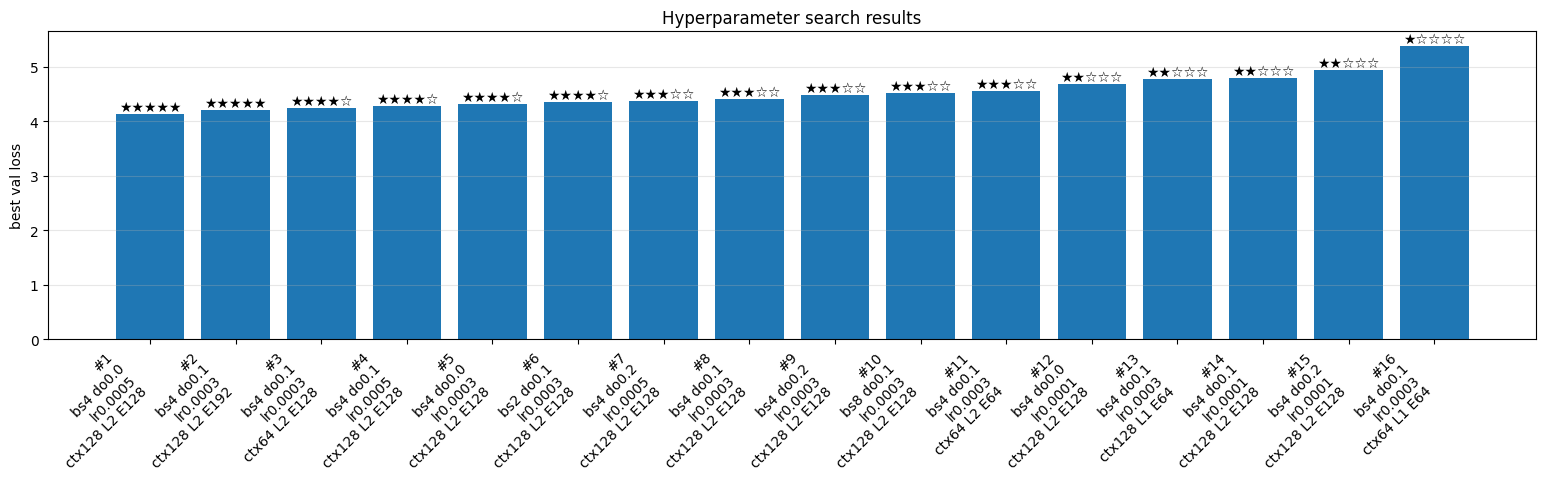

In [37]:
def plot_hparam_results(results):
    finite = [r for r in results if np.isfinite(r['best_val_loss'])]
    if not finite:
        print('No finite hparam results yet.')
        return
    ranked = sorted(finite, key=lambda r: r['best_val_loss'])
    labels = [f"#{i+1}\nbs{r['batch_size']} do{r['drop_rate']}\nlr{r['learning_rate']}\nctx{r['context_length']} L{r['n_layers']} E{r['emb_dim']}" for i, r in enumerate(ranked)]
    values = [r['best_val_loss'] for r in ranked]
    plt.figure(figsize=(max(8, len(values) * 1.2), 4))
    bars = plt.bar(range(len(values)), values)
    plt.xticks(range(len(values)), labels, rotation=45, ha='right')
    plt.ylabel('best val loss')
    plt.title('Hyperparameter search results')
    plt.grid(axis='y', alpha=0.3)
    for bar, row in zip(bars, ranked):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), row.get('stars', ''), ha='center', va='bottom')
    plt.savefig(PLOT_DIR / 'hparam_search.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_hparam_results(hparam_results)

## 4.1 Multi-seed 안정성 분석

하이퍼파라미터 탐색에서 좋아 보이는 조합도 seed가 바뀌면 성능이 흔들릴 수 있습니다. 이 섹션은 상위 조합을 여러 seed로 다시 학습해서 평균과 표준편차를 봅니다.

- 평균 validation loss가 낮을수록 전반적으로 좋은 설정입니다.
- 표준편차가 작을수록 seed에 덜 민감한 안정적인 설정입니다.
- QUICK_MODE에서는 seed를 1개만 사용하므로 구조 확인용입니다. 실제 분석은 `QUICK_MODE=False`에서 `SEEDS = [42, 123, 2024]` 이상으로 돌리는 것을 권장합니다.


In [38]:
multi_seed_lm_results = []
seed_candidates = sorted(
    [r for r in hparam_results if np.isfinite(r['best_val_loss'])],
    key=lambda r: r['best_val_loss'],
)[:1 if QUICK_MODE else 2]

for cand_idx, cand in enumerate(seed_candidates, start=1):
    for seed in SEEDS:
        set_seed(seed)
        group_name = f"seedcheck_{cand_idx}_bs{cand['batch_size']}_do{cand['drop_rate']}_lr{cand['learning_rate']}_ctx{cand['context_length']}_L{cand['n_layers']}_E{cand['emb_dim']}"
        exp_name = f"{group_name}_seed{seed}"
        print("\n===", exp_name, "===")
        config = make_gpt_config(
            vocab_size=tokenizer_vocab_size,
            context_length=cand['context_length'],
            emb_dim=cand['emb_dim'],
            n_layers=cand['n_layers'],
            drop_rate=cand['drop_rate'],
        )
        _, hist, best_path = train_lm_experiment(
            name=exp_name,
            config=config,
            train_ids=train_ids,
            val_ids=val_ids,
            batch_size=cand['batch_size'],
            lr=cand['learning_rate'],
            weight_decay=0.01,
            num_epochs=1 if QUICK_MODE else 3,
            warmup_ratio=0.1,
            grad_clip=1.0,
            eval_iter=10 if QUICK_MODE else 10,
        )
        multi_seed_lm_results.append({
            **cand,
            'experiment': exp_name,
            'experiment_group': group_name,
            'seed': seed,
            'best_val_loss': min(row['val_loss'] for row in hist),
            'best_path': str(best_path),
        })
        save_jsonl(RUN_DIR / 'multi_seed_lm_results.jsonl', multi_seed_lm_results)

lm_seed_summary = summarize_seed_results(multi_seed_lm_results, 'best_val_loss', mode='min')
print_seed_summary(lm_seed_summary)
plot_seed_summary(lm_seed_summary, 'LM multi-seed validation loss', 'lm_multi_seed_summary.png')



=== seedcheck_1_bs4_do0.0_lr0.0005_ctx128_L2_E128_seed42 ===
[seedcheck_1_bs4_do0.0_lr0.0005_ctx128_L2_E128_seed42] epoch 1/10 train=5.8442 val=4.7523 lr=0.0005
[seedcheck_1_bs4_do0.0_lr0.0005_ctx128_L2_E128_seed42] epoch 2/10 train=4.5082 val=4.3876 lr=0.000485238
[seedcheck_1_bs4_do0.0_lr0.0005_ctx128_L2_E128_seed42] epoch 3/10 train=4.2599 val=4.2322 lr=0.000442706
[seedcheck_1_bs4_do0.0_lr0.0005_ctx128_L2_E128_seed42] epoch 4/10 train=4.0941 val=4.1073 lr=0.000377533
[seedcheck_1_bs4_do0.0_lr0.0005_ctx128_L2_E128_seed42] epoch 5/10 train=3.9683 val=4.0415 lr=0.000297582
[seedcheck_1_bs4_do0.0_lr0.0005_ctx128_L2_E128_seed42] epoch 6/10 train=3.8719 val=3.9920 lr=0.000212494
[seedcheck_1_bs4_do0.0_lr0.0005_ctx128_L2_E128_seed42] epoch 7/10 train=3.7977 val=3.9648 lr=0.000132533
[seedcheck_1_bs4_do0.0_lr0.0005_ctx128_L2_E128_seed42] epoch 8/10 train=3.7423 val=3.9516 lr=6.73438e-05
[seedcheck_1_bs4_do0.0_lr0.0005_ctx128_L2_E128_seed42] epoch 9/10 train=3.7043 val=3.9469 lr=2.47885e-0

KeyboardInterrupt: 

## 5. 7.3 더 나은 감성 분류

아래 셀은 class imbalance 확인, backbone 일부 freeze, classifier/backbone learning rate 분리, best validation checkpoint 저장을 포함합니다.

### 7.3 감성 분류 실험의 목적

사전 학습된 GPT는 다음 토큰 예측을 배운 backbone입니다. 감성 분류에서는 그 backbone 위에 분류 head를 붙여 `긍정/부정`을 예측합니다.

이 실험에서 보는 포인트는 네 가지입니다.

- Class imbalance: 긍정/부정 개수가 한쪽으로 치우치면 accuracy 해석이 왜곡될 수 있습니다.
- Source distribution: 영화, 쇼핑, 게임 리뷰가 얼마나 섞였는지 확인합니다.
- Partial freeze: embedding과 일부 lower block을 얼려서 작은 데이터에서 backbone이 망가지는 것을 줄입니다.
- Split learning rate: classifier는 새로 붙인 층이라 크게 학습하고, backbone은 이미 학습된 가중치라 작게 조정합니다.

최종 모델은 validation loss가 가장 낮았던 checkpoint를 다시 불러와 test set에서 평가합니다.


In [ ]:
# 네이버 쇼핑 + Steam 한국어 리뷰를 추가로 내려받고 NSMC와 합칩니다.
# 처음 한 번만 실행하면 됩니다.
# %run download_extra_sentiment_data.py


In [ ]:
USE_COMBINED_SENTIMENT = False
active_sent_train_path = COMBINED_SENT_TRAIN_PATH if USE_COMBINED_SENTIMENT else SENT_TRAIN_PATH
active_sent_val_path = COMBINED_SENT_VAL_PATH if USE_COMBINED_SENTIMENT else SENT_VAL_PATH
active_sent_test_path = COMBINED_SENT_TEST_PATH if USE_COMBINED_SENTIMENT else SENT_TEST_PATH
print('sentiment dataset:', 'combined NSMC + shopping + steam' if USE_COMBINED_SENTIMENT else 'NSMC only')
print('train path:', active_sent_train_path)

sent_limit = 3_000 if QUICK_MODE else None
sent_train_data = load_jsonl(active_sent_train_path, limit=sent_limit)
sent_val_data = load_jsonl(active_sent_val_path, limit=1_000 if QUICK_MODE else None)
sent_test_data = load_jsonl(active_sent_test_path, limit=1_000 if QUICK_MODE else None)

label_counts = Counter(row['label'] for row in sent_train_data)
source_counts = Counter(row.get('source', 'unknown') for row in sent_train_data)
print('train label counts:', dict(label_counts))
print('train source counts:', dict(source_counts))
plt.figure(figsize=(4, 3))
plt.bar(['negative(0)', 'positive(1)'], [label_counts.get(0, 0), label_counts.get(1, 0)])
plt.title('Sentiment class balance')
plt.ylabel('count')
plt.savefig(PLOT_DIR / 'sentiment_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6, 3))
plt.bar(list(source_counts.keys()), list(source_counts.values()))
plt.title('Sentiment source distribution')
plt.ylabel('count')
plt.xticks(rotation=20, ha='right')
plt.savefig(PLOT_DIR / 'sentiment_source_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

sent_context_length = base_config['context_length']
sent_batch_size = 8 if QUICK_MODE else 32

def build_cached_sentiment_dataset(name, data, tokenizer, max_length):
    mode_name = 'quick' if QUICK_MODE else 'full'
    source_name = 'combined' if USE_COMBINED_SENTIMENT else 'nsmc'
    cache_path = RUN_DIR / f'sent_{source_name}_{name}_ids_{mode_name}_v{tokenizer_vocab_size}_ctx{max_length}.pt'
    if cache_path.exists():
        cached = torch.load(cache_path, map_location='cpu')
        print('loaded cached sentiment ids:', cache_path)
        return TensorDataset(cached['input_ids'], cached['labels'])

    pad_id = tokenizer.get_pad_id()
    input_ids = []
    labels = []
    for i, item in enumerate(data, start=1):
        token_ids = tokenizer.encode(item['text'], add_bos_eos=True)
        token_ids = token_ids[:max_length]
        token_ids += [pad_id] * (max_length - len(token_ids))
        input_ids.append(token_ids)
        labels.append(int(item['label']))
        if i % 10000 == 0:
            print(f'encoded {name}: {i}/{len(data)}')

    input_tensor = torch.tensor(input_ids, dtype=torch.long)
    label_tensor = torch.tensor(labels, dtype=torch.long)
    torch.save({'input_ids': input_tensor, 'labels': label_tensor}, cache_path)
    print('encoded and saved sentiment ids:', cache_path)
    return TensorDataset(input_tensor, label_tensor)

train_ds = build_cached_sentiment_dataset('train', sent_train_data, tokenizer, sent_context_length)
val_ds = build_cached_sentiment_dataset('val', sent_val_data, tokenizer, sent_context_length)
test_ds = build_cached_sentiment_dataset('test', sent_test_data, tokenizer, sent_context_length)
train_loader = DataLoader(train_ds, batch_size=sent_batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=sent_batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=sent_batch_size, shuffle=False)

In [ ]:
def load_lm_backbone_for_classification(config, checkpoint_path=None):
    gpt = GPTModel(config)
    if checkpoint_path is not None and Path(checkpoint_path).exists():
        ckpt = torch.load(checkpoint_path, map_location='cpu')
        state = ckpt.get('model_state_dict', ckpt)
        gpt.load_state_dict(state, strict=False)
        print('loaded LM backbone:', checkpoint_path)
    return gpt

def freeze_backbone(model, mode='embeddings_and_lower_blocks'):
    for p in model.gpt.parameters():
        p.requires_grad = True
    if mode == 'none':
        return
    if mode in {'all', 'backbone'}:
        for p in model.gpt.parameters():
            p.requires_grad = False
        return
    if mode == 'embeddings_and_lower_blocks':
        for p in model.gpt.tok_emb.parameters():
            p.requires_grad = False
        for p in model.gpt.pos_emb.parameters():
            p.requires_grad = False
        n_blocks = len(model.gpt.trf_blocks)
        freeze_blocks = max(0, n_blocks // 2)
        for block in list(model.gpt.trf_blocks)[:freeze_blocks]:
            for p in block.parameters():
                p.requires_grad = False

def make_discriminative_optimizer(model, backbone_lr=1e-5, classifier_lr=3e-4, weight_decay=0.01):
    backbone_params = [p for p in model.gpt.parameters() if p.requires_grad]
    head_params = [p for name, p in model.named_parameters() if not name.startswith('gpt.') and p.requires_grad]
    groups = []
    if backbone_params:
        groups.append({'params': backbone_params, 'lr': backbone_lr, 'weight_decay': weight_decay})
    if head_params:
        groups.append({'params': head_params, 'lr': classifier_lr, 'weight_decay': weight_decay})
    return torch.optim.AdamW(groups)

def train_sentiment_experiment(name, config, lm_checkpoint=None, freeze_mode='embeddings_and_lower_blocks',
                               backbone_lr=1e-5, classifier_lr=3e-4, weight_decay=0.01,
                               num_epochs=3, grad_clip=1.0, use_cache=True):
    gpt = load_lm_backbone_for_classification(config, lm_checkpoint)
    model = GPTForSequenceClassification(gpt, num_labels=2, drop_rate=config.get('drop_rate', 0.1)).to(device)
    best_path = CKPT_DIR / f'{name}_best_sentiment.pt'
    if use_cache and best_path.exists():
        ckpt = torch.load(best_path, map_location=device)
        saved_config = ckpt.get('config')
        history = ckpt.get('history', [])
        saved_args = history[-1] if history else {}
        args_match = (
            saved_args.get('freeze_mode') == freeze_mode
            and saved_args.get('backbone_lr') == backbone_lr
            and saved_args.get('classifier_lr') == classifier_lr
            and len(history) >= num_epochs
        )
        if saved_config == config and args_match:
            model.load_state_dict(ckpt['model_state_dict'])
            test_loss, test_acc = evaluate_sentiment(model, test_loader, device)
            print('loaded cached sentiment checkpoint:', best_path)
            print(f'cached checkpoint test_loss={test_loss:.4f} test_acc={test_acc:.3f}')
            return model, history, best_path, {'test_loss': float(test_loss), 'test_acc': float(test_acc)}
        print('checkpoint exists but config changed, retraining:', best_path)

    freeze_backbone(model, freeze_mode)
    optimizer = make_discriminative_optimizer(model, backbone_lr, classifier_lr, weight_decay)
    history = []
    best_val_loss = float('inf')

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_loss = 0.0
        correct = 0
        examples = 0
        for input_batch, target_batch in train_loader:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss, logits = model(input_batch, target_batch)
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], grad_clip)
            optimizer.step()

            batch_size = target_batch.size(0)
            total_loss += loss.item() * batch_size
            correct += (logits.argmax(dim=-1) == target_batch).sum().item()
            examples += batch_size

        train_loss = total_loss / examples
        train_acc = correct / examples
        val_loss, val_acc = evaluate_sentiment(model, val_loader, device)
        row = {
            'experiment': name,
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': float(val_loss),
            'val_acc': float(val_acc),
            'freeze_mode': freeze_mode,
            'backbone_lr': backbone_lr,
            'classifier_lr': classifier_lr,
            'weight_decay': weight_decay,
        }
        history.append(row)
        print(f"[{name}] epoch {epoch}/{num_epochs} train_loss={train_loss:.4f} train_acc={train_acc:.3f} val_loss={val_loss:.4f} val_acc={val_acc:.3f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({'model_state_dict': model.state_dict(), 'config': config, 'history': history}, best_path)

    best = torch.load(best_path, map_location=device)
    model.load_state_dict(best['model_state_dict'])
    test_loss, test_acc = evaluate_sentiment(model, test_loader, device)
    print(f'best checkpoint test_loss={test_loss:.4f} test_acc={test_acc:.3f}')
    return model, history, best_path, {'test_loss': float(test_loss), 'test_acc': float(test_acc)}

sent_epochs = 1 if QUICK_MODE else 5
sent_model, sent_history, sent_best_path, sent_test = train_sentiment_experiment(
    name='sentiment_freeze_split_lr',
    config=base_config,
    lm_checkpoint=lm_best_path,
    freeze_mode='embeddings_and_lower_blocks',
    backbone_lr=1e-5,
    classifier_lr=3e-4,
    weight_decay=0.01,
    num_epochs=sent_epochs,
)
save_jsonl(RUN_DIR / 'sentiment_history.jsonl', sent_history)
plot_metric(sent_history, 'Sentiment loss', ['train_loss', 'val_loss'], 'sentiment_loss.png')
plot_metric(sent_history, 'Sentiment accuracy', ['train_acc', 'val_acc'], 'sentiment_accuracy.png')
print('best sentiment checkpoint:', sent_best_path)
print('test:', sent_test)

## 5.1 감성 분류 multi-seed 분석

감성 분류도 데이터 셔플, classifier 초기화, dropout 때문에 seed에 따라 accuracy가 달라질 수 있습니다. 같은 설정을 여러 seed로 반복해 validation/test 성능의 평균과 표준편차를 확인합니다.


In [ ]:
multi_seed_sentiment_results = []

for seed in SEEDS:
    set_seed(seed)
    exp_name = f"sentiment_freeze_split_lr_seed{seed}"
    print("\n===", exp_name, "===")
    _, hist, best_path, test_result = train_sentiment_experiment(
        name=exp_name,
        config=base_config,
        lm_checkpoint=lm_best_path,
        freeze_mode='embeddings_and_lower_blocks',
        backbone_lr=1e-5,
        classifier_lr=3e-4,
        weight_decay=0.01,
        num_epochs=1 if QUICK_MODE else 3,
    )
    multi_seed_sentiment_results.append({
        'experiment': exp_name,
        'experiment_group': 'sentiment_freeze_split_lr',
        'seed': seed,
        'best_val_loss': min(row['val_loss'] for row in hist),
        'best_val_acc': max(row['val_acc'] for row in hist),
        'test_loss': test_result['test_loss'],
        'test_acc': test_result['test_acc'],
        'best_path': str(best_path),
    })
    save_jsonl(RUN_DIR / 'multi_seed_sentiment_results.jsonl', multi_seed_sentiment_results)

sent_loss_summary = summarize_seed_results(multi_seed_sentiment_results, 'best_val_loss', mode='min')
sent_acc_summary = summarize_seed_results(multi_seed_sentiment_results, 'test_acc', mode='max')
print('Validation loss summary')
print_seed_summary(sent_loss_summary)
print('\nTest accuracy summary')
print_seed_summary(sent_acc_summary)
plot_seed_summary(sent_loss_summary, 'Sentiment multi-seed validation loss', 'sentiment_multi_seed_val_loss.png')
plot_seed_summary(sent_acc_summary, 'Sentiment multi-seed test accuracy', 'sentiment_multi_seed_test_acc.png')


## 6. 최종 요약

### 최종 요약 해석

마지막 셀은 실험 결과를 `runs/experiment_summary.json`에 저장합니다.

- `lm_best_val_loss`: 사전 학습 모델 중 가장 낮은 validation loss입니다.
- `hparam_best`: 하이퍼파라미터 탐색 상위 조합입니다.
- `sentiment_best_val_loss`: 감성 분류 validation loss 최저값입니다.
- `sentiment_best_val_acc`: 감성 분류 validation accuracy 최고값입니다.
- `sentiment_test`: validation loss 기준으로 고른 best checkpoint의 test 성능입니다.

보고서에는 그래프 이미지와 이 요약 JSON을 함께 보면 실험 근거를 정리하기 쉽습니다.


In [ ]:
summary = {
    'lm_best_checkpoint': str(lm_best_path),
    'lm_best_val_loss': min(row['val_loss'] for row in lm_history),
    'hparam_best': sorted([r for r in hparam_results if np.isfinite(r['best_val_loss'])], key=lambda r: r['best_val_loss'])[:5],
    'sentiment_best_checkpoint': str(sent_best_path),
    'sentiment_best_val_loss': min(row['val_loss'] for row in sent_history),
    'sentiment_best_val_acc': max(row['val_acc'] for row in sent_history),
    'sentiment_test': sent_test,
}
(RUN_DIR / 'experiment_summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')

print('===== Experiment Summary =====')
print('LM best val loss:', summary['lm_best_val_loss'], star_rating(summary['lm_best_val_loss'], summary['lm_best_val_loss'], 'min'))
print('Sentiment best val loss:', summary['sentiment_best_val_loss'])
print('Sentiment best val acc:', summary['sentiment_best_val_acc'], star_rating(summary['sentiment_best_val_acc'], summary['sentiment_best_val_acc'], 'max'))
print('Sentiment test:', summary['sentiment_test'])
print('Saved summary:', RUN_DIR / 'experiment_summary.json')